# 07 — Analisis Performa Siswa

Pernahkah kamu bertanya-tanya: faktor apa saja yang memengaruhi nilai ujian siswa?
Apakah latar belakang pendidikan orang tua, jenis kelamin, atau persiapan ujian
benar-benar berpengaruh? Di notebook ini kita akan menjawabnya dengan **data nyata**.

> 🎯 **Tujuan Pembelajaran**
> - Membaca data nilai siswa dan memahami strukturnya.
> - Membandingkan rata-rata skor antar kelompok (gender, lunch, test prep).
> - Membuat **crosstab** dan menghitung **korelasi** antar nilai.
> - Memvisualisasikan perbedaan grup dengan boxplot dan bar chart.

## 📊 Tentang Dataset

Kita memakai **Students Performance in Exams**, berisi nilai ujian 1000 siswa beserta
beberapa atribut demografis dan latar belakang mereka.

- **Sumber:** [Kaggle — spscientist/students-performance-in-exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)
- **Jumlah data:** 1000 baris × 8 kolom

| Kolom | Arti |
|-------|------|
| `gender` | Jenis kelamin siswa |
| `race/ethnicity` | Kelompok etnis (anonim: group A–E) |
| `parental level of education` | Tingkat pendidikan orang tua |
| `lunch` | Jenis makan siang (standard / free-reduced — proksi kondisi ekonomi) |
| `test preparation course` | Apakah mengikuti kursus persiapan ujian |
| `math score` | Nilai matematika (0–100) |
| `reading score` | Nilai membaca (0–100) |
| `writing score` | Nilai menulis (0–100) |

## 1. Import Library

- **pandas** → membaca & mengolah tabel data.
- **numpy** → operasi angka.
- **matplotlib** & **seaborn** → membuat grafik.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Instal Kaggle
!pip install -q kaggle

# Pastikan file kaggle.json sudah di-upload ke Colab
# Jalankan perintah ini untuk mendownload dan unzip otomatis
!kaggle datasets download spscientist/students-performance-in-exams

Dataset URL: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
License(s): unknown
100% 8.70k/8.70k [00:00<00:00, 18.4MB/s]



##  Eksplorasi Awal

Mari lihat beberapa baris pertama untuk memahami bentuk datanya.

In [3]:
df = pd.read_csv('/content/students-performance-in-exams.zip')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Interpretasi :
  - Setiap Baris ini Mewakili 1 entitas seorang siswa
  - Terdapat 3 kolom numerik (score)
  - Terdapat 5 kolom categorical (Teks)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.isna().sum().sum()

np.int64(0)

Interpretasi :
  - Terdiri dari 1000 baris dan 8 Kolom
  - Tidak terdapat nilai yang hilang


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


Interpretasi :
  - Nilai rata rata ketiga mata pelajaran di angka 66 - 69
  - Nilai terendah math ada di angka 0
  - Nilai terendah Read dan Write ada di angka 17 dan 10
  - Standar Deviasi ada diangka 14,6 - 15.2 untuk ketiga mata pelajaran ini, menandakan variasi nilai setiap siswa cukup besar


## Pembersihan Data

Datanya sudah bersih, tetapi nama kolom mengandung spasi yang merepotkan untuk diketik.
Kita juga akan membuat satu kolom bantu **`average score`** (rata-rata 3 nilai) agar analisis perbandingan grup lebih ringkas.

In [9]:
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 0


In [11]:
#Buat kolom baru untuk rata rata
df['average score'] = ((df['math score'] + df['reading score'] + df['writing score']) / 3).round(2)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


Interpretasi :
  - Kolom Avarege dibuat untuk mempermudah dan merangkum performa setiap siswa, dengan maksud kolom ini menjadi label atau y terhadap nilai x atau fitur

## EDA & Visualisasi

Sekarang kita gali pola dalam data lewat grafik.

### a) distribusi nilai rata rata (histogram)

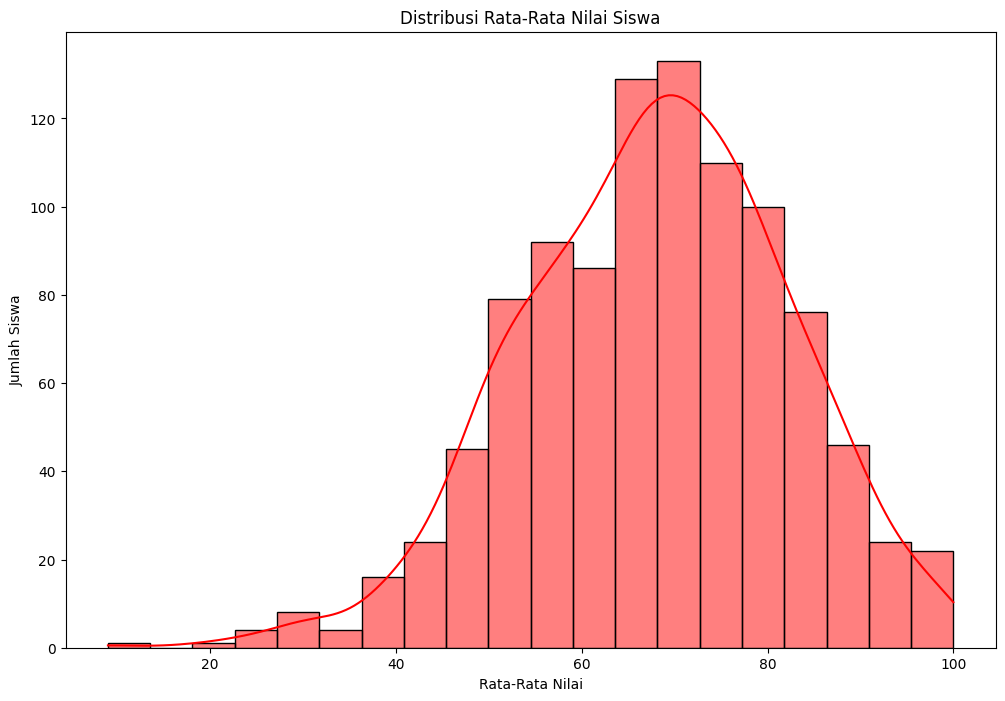

In [13]:
plt.figure(figsize=(12,8))
sns.histplot(df["average score"], bins=20, kde=True, color="red")
plt.title("Distribusi Rata-Rata Nilai Siswa")
plt.xlabel("Rata-Rata Nilai")
plt.ylabel("Jumlah Siswa")
plt.show()

Interpretasi :
  - Distribusi mendekati distribusi normal, berbentuk lonceng dengan puncak diangka score 68-70
  - Sedikit siswa yang memiliki nilai kecil dibawah score 45
  - Sedikit juga siswa yang memiliki nilai besar diatas score 85


### b) Perbandingan skor matematika berdasarkan jenis kelamin (boxplot)

/tmp/ipykernel_544/695920050.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender", y="math score", data=df, palette="mako")


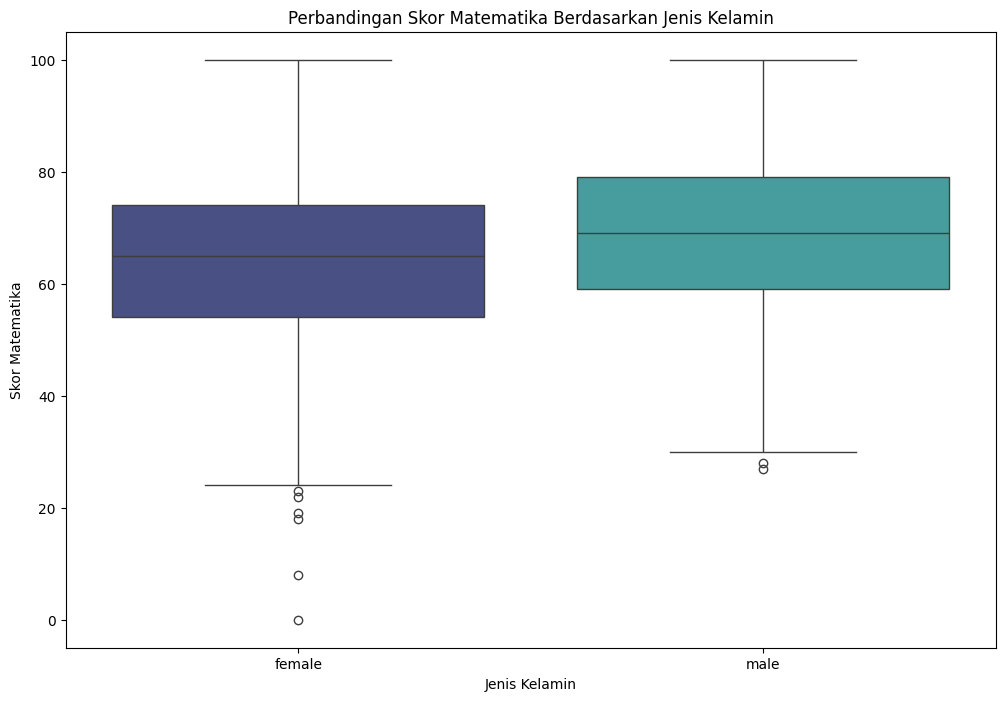

In [15]:
plt.figure(figsize=(12,8))
sns.boxplot(x="gender", y="math score", data=df, palette="mako")
plt.title("Perbandingan Skor Matematika Berdasarkan Jenis Kelamin")
plt.xlabel("Jenis Kelamin")
plt.ylabel("Skor Matematika")
plt.show()


Interpretasi :
  - Rentang nilai perempuan berpusat diangka score 55-76
  - Rentang nilai Lakilaki berpusat diangka score 59-79, sedikit lebih tinggi dibanding perempuan
  - Untuk rata rata nilai matematika terendah ada dipihak perempuan

### c) Pengaruh kursus persiapan ujian terhadap rata-rata skor (bar chart)

/tmp/ipykernel_544/3932919828.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='test preparation course', y='average score', data=rata_prepa, palette="mako")


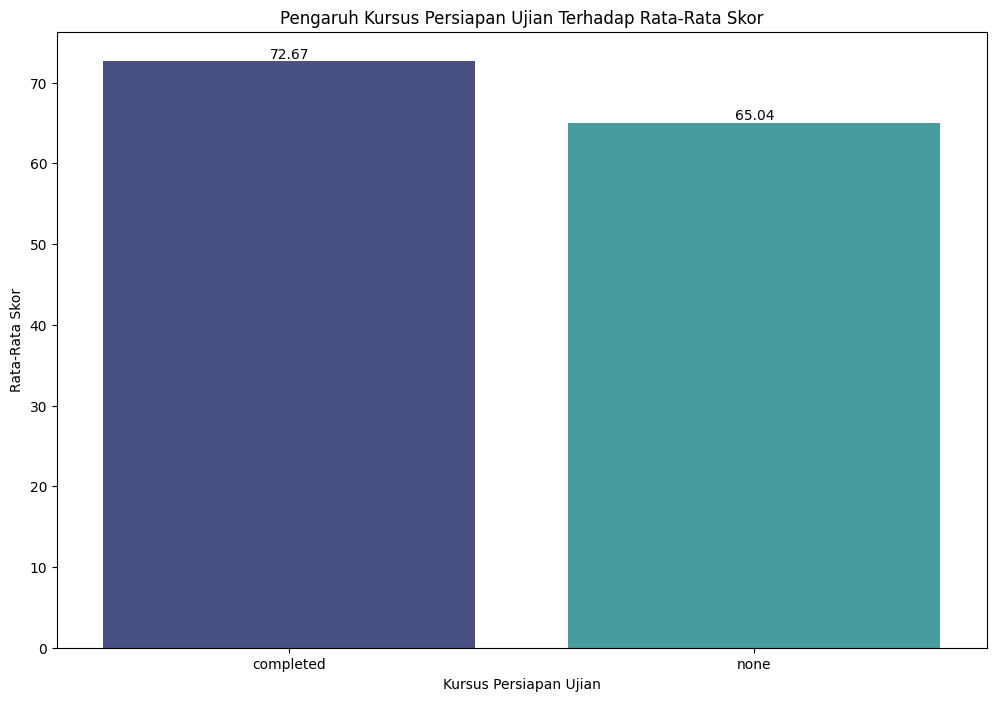

In [17]:
rata_prepa = df.groupby('test preparation course')['average score'].mean().reset_index()
plt.figure(figsize=(12,8))
sns.barplot(x='test preparation course', y='average score', data=rata_prepa, palette="mako")
plt.title("Pengaruh Kursus Persiapan Ujian Terhadap Rata-Rata Skor")
plt.xlabel("Kursus Persiapan Ujian")
plt.ylabel("Rata-Rata Skor")
for index, row in rata_prepa.iterrows():
    plt.text(row.name, row['average score'], round(row['average score'], 2), ha='center', va='bottom')
plt.show()

Interpretasi :
  - Siswa yang mengikuti kursus nilainya lebih tinggi daripada siswa yang tidak mengikuti persiapan kursus, dan memiliki nilai rata rata score 7.7 point lebih tinggi daripada siswa yang tidak mengikuti kursus persiapan ujian

### d) Pengaruh jenis makan siang (lunch) per mata pelajaran

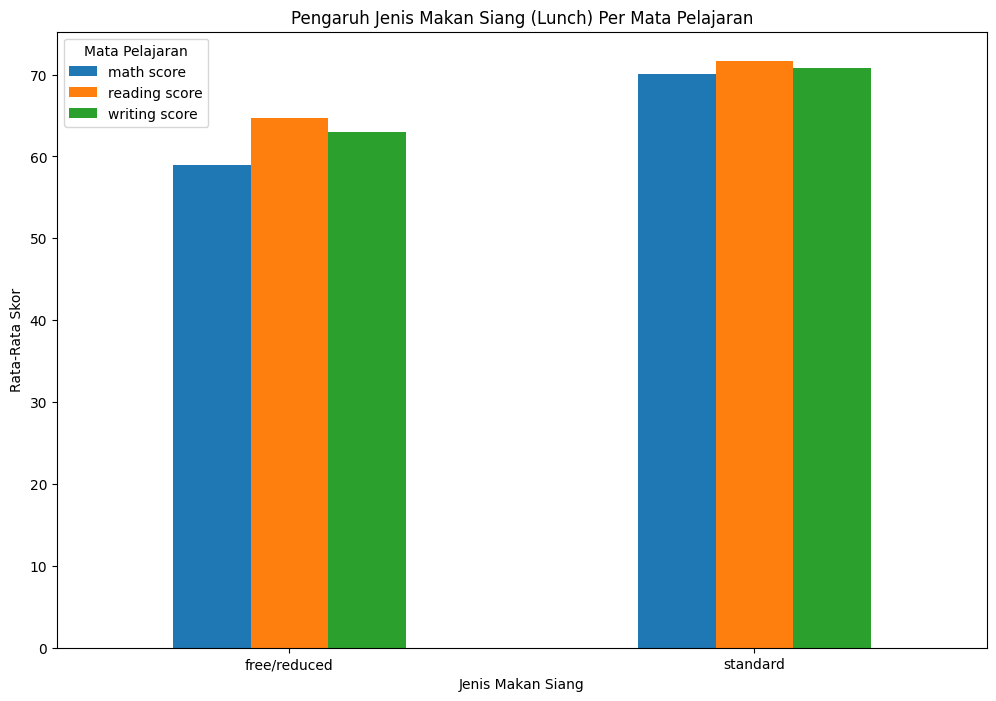

In [21]:
rate_lunch = df.groupby('lunch')[["math score","reading score","writing score"]].mean()
rate_lunch.plot(kind="bar", figsize=(12,8))
plt.title("Pengaruh Jenis Makan Siang (Lunch) Per Mata Pelajaran")
plt.xlabel("Jenis Makan Siang")
plt.ylabel("Rata-Rata Skor")
plt.xticks(rotation=0)
plt.legend(title="Mata Pelajaran")
plt.show()

Interpretasi :
  -  Siswa yang makan siang terstandard memiliki nilai rata rata score lebih tinggi daripada siswa yang mendapat makan siang gratis
  - rata rata nilai dari makanan yang terstandard ini konsisten lebih tinggi dalam semua mata pelajaran
  - mengindikasikan adanya kesenjangan ekonomi yang berpengaruh terhadap performace siswa dan pola pikir siswa


### e) Korelasi antar nilai (heatmap)

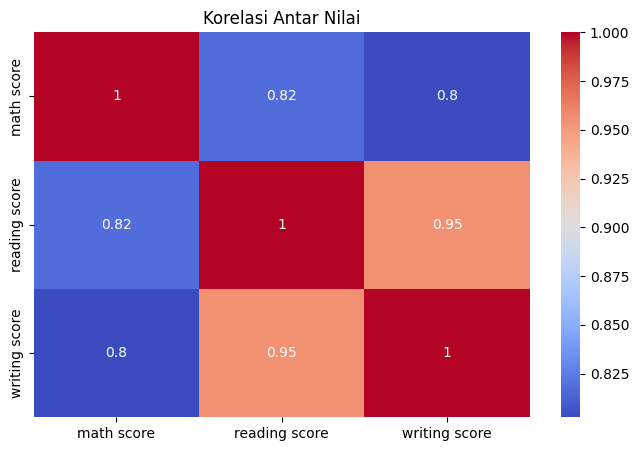

In [26]:
corelate_val = df[["math score","reading score","writing score"]].corr()
plt.figure(figsize=(8,5))
sns.heatmap(corelate_val, annot=True, cmap="coolwarm")
plt.title("Korelasi Antar Nilai")
plt.show()

Interpretasi :
  - ada kolerasi yang kuat antara kemampuan menulis dan membaca


### f) Crosstab: lunch × test preparation course

In [27]:
Ct_lunch = pd.crosstab(df["lunch"], df["test preparation course"])
Ct_lunch

test preparation course,completed,none
lunch,,
free/reduced,131,224
standard,227,418


Interpretasi :
  -  Banyak siswa yang tidak mengikuti agenda test preparation, terlepas dari jenis makan siangnya

### g) Uji statistik: apakah selisih kursus persiapan signifikan?

Grafik menunjukkan siswa yang ikut kursus persiapan punya rata-rata lebih tinggi. Tapi **apakah selisih itu nyata, atau cuma kebetulan sampel?** Kita uji dengan **independent t-test**. Aturan praktis: jika **p-value < 0.05**, selisihnya dianggap signifikan secara statistik.

In [28]:
from scipy import stats

In [35]:
ikut_prepa = df[df["test preparation course"] == "completed"]["average score"]
tidak_ikut_prepa = df[df["test preparation course"] == "none"]["average score"]

In [37]:
t_stat, p_value = stats.ttest_ind(ikut_prepa, tidak_ikut_prepa)


print(f"nilai rata-rata tidak kursur : {tidak_ikut_prepa.mean():.2f}")
print(f"nilai rata-rata kursur       : {ikut_prepa.mean():.2f}")
print(f"selisis                      : {ikut_prepa.mean() - tidak_ikut_prepa.mean():.2f}")
print(f"t-statistic = {t_stat:.2f} | p-value = {p_value:.2e}")
print("Kesimpulan:" , "Signifikan (p<0.05)" if p_value < 0.05 else "tidak signifikan")

nilai rata-rata tidak kursur : 65.04
nilai rata-rata kursur       : 72.67
selisis                      : 7.63
t-statistic = 8.39 | p-value = 1.63e-16
Kesimpulan: Signifikan (p<0.05)


Interpretasi :

  - Nilai Rata-rata Tidak Kursus (65.04): Skor rata-rata dari kelompok yang tidak mengikuti kursus.
  - Nilai Rata-rata Kursus (72.67): Skor rata-rata dari kelompok yang mengikuti kursus. Kelompok ini memiliki rata-rata yang lebih tinggi.
  - Selisih (7.63): Besarnya perbedaan skor rata-rata antara kedua kelompok ($72.67 - 65.04 = 7.63$). Mengikuti kursus memberikan peningkatan rata-rata sebesar 7.63 poin.
  - t-statistic = 8.39: Nilai uji statistik t. Semakin jauh nilai t dari angka nol (baik positif maupun negatif), semakin besar perbedaan antar kelompok. Angka 8.39 menunjukkan perbedaan yang sangat kentara.
  - p-value = $1.63e-16$ ($0.000000000000000163$): Angka probabilitas untuk melihat apakah perbedaan tersebut terjadi secara kebetulan semata. Karena nilainya jauh di bawah ambang batas standar signifikansi ($0.05$), kemungkinannya sangat kecil bahwa hasil ini terjadi karena kebetulan.
  - Kesimpulan: Signifikan ($p < 0.05$): Secara statistik, perbedaan skor antara yang kursus dan tidak kursus terbukti benar-benar bermakna, bukan sekadar faktor kebetulan.
  
  
  Kesimpulan Utama: Mengikuti kursus memberikan dampak atau peningkatan skor yang signifikan secara statistik terhadap nilai yang diperoleh.


## Kesimpulan & Insight

- Distribusi nilai siswa mendekati normal dengan rata-rata ~68.
- **Kursus persiapan ujian** memberi kenaikan rata-rata sekitar **7 poin** — faktor yang bisa ditindaklanjuti sekolah.
- **Jenis lunch** (proksi ekonomi) berkaitan dengan performa di semua mata pelajaran → sinyal kesenjangan.
- Nilai **membaca & menulis** hampir selalu sejalan; intervensi literasi bisa mengangkat keduanya.
- Perbedaan gender ada tetapi kecil dan tergantung mata pelajaran.



**Rekomendasi:** Sekolah dapat mendorong lebih banyak siswa mengikuti kursus persiapan
dan memberi dukungan tambahan bagi siswa dari latar ekonomi kurang mampu.

## 💼 Rekomendasi & Insight Bisnis

Untuk pihak sekolah/dinas pendidikan:
  - (1) **perluas akses kursus persiapan** — dampaknya pada nilai terbukti signifikan secara statistik;
  - (2) **beri dukungan tambahan** bagi siswa dari latar ekonomi kurang mampu, karena terlihat kesenjangan performa yang konsisten di semua mata pelajaran.

### ⚠️ Jebakan Data
Kolom `lunch` hanya **proksi** kondisi ekonomi, bukan ukuran pendapatan langsung. Boleh dipakai sebagai indikasi, tapi **jangan disimpulkan sebagai sebab-akibat** ("makan siang gratis menurunkan nilai"). Yang sebenarnya berperan adalah kondisi ekonomi yang lebih luas di baliknya.

Interpretasi :
